# Advanced Deep Learning Walkthrough

**Forest Cover Type Classification with PyTorch**

In this walkthrough, we'll build increasingly sophisticated neural networks using PyTorch. We'll start with a baseline model and progressively add:

1. **Regularization** - L2 and Dropout
2. **Batch Normalization** - Stabilizing training
3. **Learning Rate Scheduling** - Adaptive learning rates

By the end, you'll have a solid toolkit for building and tuning deep learning models.

---

## Section 1: Setup & Data Loading

Let's start by importing our libraries and loading the Forest Cover Type dataset.

In [28]:
# Core PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import fetch_covtype

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


The Forest Cover Type dataset contains cartographic data from the US Forest Service. Our task is to predict the forest cover type (7 classes) from 54 features including elevation, slope, soil type, and wilderness area.

**Why this dataset?** With 581,012 samples, it's large enough to demonstrate realistic deep learning training times and the impact of our advanced techniques!

In [29]:
# Load the Forest Cover Type dataset from sklearn
# This may take a moment to download (~50MB)
covtype = fetch_covtype()

# Get features and target
X = covtype.data
y = covtype.target - 1  # Convert from 1-7 to 0-6 for PyTorch

# Display basic info about our dataset
print("=" * 50)
print("FOREST COVER TYPE DATASET")
print("=" * 50)
print(f"\nDataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt:,} samples ({cnt/len(y)*100:.1f}%)")

FOREST COVER TYPE DATASET

Dataset shape: (581012, 54)
Number of features: 54
Number of classes: 7

Class distribution:
  Class 0: 211,840 samples (36.5%)
  Class 1: 283,301 samples (48.8%)
  Class 2: 35,754 samples (6.2%)
  Class 3: 2,747 samples (0.5%)
  Class 4: 9,493 samples (1.6%)
  Class 5: 17,367 samples (3.0%)
  Class 6: 20,510 samples (3.5%)


In [30]:
# Show feature statistics
print("\nFeature Statistics (first 10 features):")
print(f"  Min values: {X[:, :10].min(axis=0)}")
print(f"  Max values: {X[:, :10].max(axis=0)}")
print(f"\nNote: Features include elevation, aspect, slope, distances,")
print(f"      wilderness areas (binary), and soil types (binary)")
print(f"\nFirst 5 samples:")
print(X[:5, :10])  # Show first 10 features of first 5 samples


Feature Statistics (first 10 features):
  Min values: [1859.    0.    0.    0. -173.    0.    0.    0.    0.    0.]
  Max values: [3858.  360.   66. 1397.  601. 7117.  254.  254.  254. 7173.]

Note: Features include elevation, aspect, slope, distances,
      wilderness areas (binary), and soil types (binary)

First 5 samples:
[[ 2.596e+03  5.100e+01  3.000e+00  2.580e+02  0.000e+00  5.100e+02
   2.210e+02  2.320e+02  1.480e+02  6.279e+03]
 [ 2.590e+03  5.600e+01  2.000e+00  2.120e+02 -6.000e+00  3.900e+02
   2.200e+02  2.350e+02  1.510e+02  6.225e+03]
 [ 2.804e+03  1.390e+02  9.000e+00  2.680e+02  6.500e+01  3.180e+03
   2.340e+02  2.380e+02  1.350e+02  6.121e+03]
 [ 2.785e+03  1.550e+02  1.800e+01  2.420e+02  1.180e+02  3.090e+03
   2.380e+02  2.380e+02  1.220e+02  6.211e+03]
 [ 2.595e+03  4.500e+01  2.000e+00  1.530e+02 -1.000e+00  3.910e+02
   2.200e+02  2.340e+02  1.500e+02  6.172e+03]]


### Prepare Data for PyTorch

We need to:
1. Split into train/validation/test sets
2. Scale the features (important for neural networks!)
3. **Convert to PyTorch tensors** - PyTorch doesn't work with NumPy arrays directly. We need to convert our data into `torch.Tensor` objects, which are like NumPy arrays but can run on GPUs and track gradients.
4. **Create DataLoaders for batching** - A `DataLoader` is like a smart conveyor belt: it automatically splits your dataset into small batches and feeds them to the model one batch at a time. This is more memory-efficient than feeding all 50K samples at once.

In [31]:
# Use a subset of 50K samples to keep training times manageable
SAMPLE_SIZE = 50000

np.random.seed(42)
indices = np.random.choice(len(X), SAMPLE_SIZE, replace=False)
X_sampled = X[indices]
y_sampled = y[indices]

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_sampled, y_sampled, 
    test_size=0.2, 
    random_state=42,
    stratify=y_sampled  # Maintain class balance in splits
)

# Second split: 75% train, 25% val (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    random_state=42,
    stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")

Training set:   30,000 samples
Validation set: 10,000 samples
Test set:       10,000 samples


In [32]:
# Scale features using StandardScaler
# IMPORTANT: Fit on training data only, then transform all sets
scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using the SAME scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - Training data statistics:")
print(f"  Mean: {X_train.mean(axis=0)[:3]}...")  # Show first 3 features
print(f"  Std:  {X_train.std(axis=0)[:3]}...")

print("\nAfter scaling - Training data statistics:")
print(f"  Mean: {X_train_scaled.mean(axis=0)[:3]}...")  # Should be ~0
print(f"  Std:  {X_train_scaled.std(axis=0)[:3]}...")   # Should be ~1

Before scaling - Training data statistics:
  Mean: [2962.53616667  155.95243333   14.0842    ]...
  Std:  [277.5847931  111.84167219   7.47604466]...

After scaling - Training data statistics:
  Mean: [-3.12574041e-16 -1.01785247e-16  1.33501543e-16]...
  Std:  [1. 1. 1.]...


In [33]:
# Convert to PyTorch tensors
# Think of tensors as NumPy arrays that PyTorch can work with
# float32 = decimal numbers (for features), long = whole numbers (for class labels)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"X_train tensor shape: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"y_train tensor shape: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")

X_train tensor shape: torch.Size([30000, 54]), dtype: torch.float32
y_train tensor shape: torch.Size([30000]), dtype: torch.int64


In [34]:
# TensorDataset pairs each feature row with its label (like zip() but for tensors)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader = automatic batch maker
# Instead of feeding all 50K samples at once, it serves them in small batches of 64
# Think of it like a restaurant serving plates of food instead of dumping everything on the table
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True  # Shuffle training data each epoch so the model doesn't memorize the order
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False  # No need to shuffle validation data
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

# Let's peek at one batch to see what the DataLoader gives us
sample_batch_X, sample_batch_y = next(iter(train_loader))
print(f"\nSample batch - Features shape: {sample_batch_X.shape}")
print(f"Sample batch - Labels shape: {sample_batch_y.shape}")
print(f"Sample batch - Labels: {sample_batch_y}")

Number of training batches: 469
Number of validation batches: 157

Sample batch - Features shape: torch.Size([64, 54])
Sample batch - Labels shape: torch.Size([64])
Sample batch - Labels: tensor([0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
        6, 0, 1, 5, 0, 0, 0, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 1, 1, 4, 0, 0,
        1, 2, 1, 0, 0, 6, 1, 0, 2, 1, 0, 0, 6, 1, 1, 1])


---

## Section 2: Baseline Model

Let's build a simple feedforward neural network (MLP) as our baseline. No fancy techniques yet - just basic layers and training.

**PyTorch Model Basics:**
- Every model is a Python **class** that inherits from `nn.Module`
- `__init__` is where you **define your layers** (like picking building blocks)
- `forward` is where you **connect them** (like assembling the blocks)
- `.to(device)` moves the model to GPU if available (for faster training)

In [35]:
class BaselineModel(nn.Module):
    """
    A simple feedforward neural network for forest cover type classification.
    
    Architecture:
    - Input: 54 features
    - Hidden 1: 64 neurons, ReLU
    - Hidden 2: 32 neurons, ReLU
    - Output: 7 classes
    """
    
    def __init__(self, input_size=54, hidden1=64, hidden2=32, num_classes=7):
        # super().__init__() tells PyTorch "set up all the behind-the-scenes stuff"
        super(BaselineModel, self).__init__()
        
        # nn.Linear = a fully connected layer (like Dense in Keras)
        # nn.Linear(54, 64) means: 54 inputs -> 64 outputs
        self.fc1 = nn.Linear(input_size, hidden1)  # First hidden layer
        self.fc2 = nn.Linear(hidden1, hidden2)      # Second hidden layer
        self.fc3 = nn.Linear(hidden2, num_classes)  # Output layer
        
        # Activation function
        self.relu = nn.ReLU()
    
    def forward(self, x):
        """Forward pass - this defines how data flows through the network."""
        # Layer 1: Linear -> ReLU
        x = self.fc1(x)
        x = self.relu(x)
        
        # Layer 2: Linear -> ReLU
        x = self.fc2(x)
        x = self.relu(x)
        
        # Output layer: Linear only (no activation here!)
        # CrossEntropyLoss will handle softmax internally
        x = self.fc3(x)
        
        return x


# Create the model and move to device (GPU if available, otherwise CPU)
baseline_model = BaselineModel().to(device)

# Print model architecture
print("BASELINE MODEL ARCHITECTURE")
print("=" * 40)
print(baseline_model)

# Count parameters (weights and biases the model will learn)
total_params = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

BASELINE MODEL ARCHITECTURE
BaselineModel(
  (fc1): Linear(in_features=54, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)

Total parameters: 5,831
Trainable parameters: 5,831


### Training Loop

The PyTorch training loop has 5 key steps that repeat every batch:

1. **`optimizer.zero_grad()`** - Clear old gradients (PyTorch accumulates them by default)
2. **`outputs = model(batch_X)`** - Forward pass: feed data through the network
3. **`loss = criterion(outputs, batch_y)`** - Calculate how wrong the predictions are
4. **`loss.backward()`** - Backward pass: compute gradients (how to adjust each weight)
5. **`optimizer.step()`** - Update the weights using those gradients

Also important:
- **`model.train()`** - Tells PyTorch "we're training" (enables dropout, updates batch norm)
- **`model.eval()`** - Tells PyTorch "we're evaluating" (disables dropout, freezes batch norm)
- **`torch.no_grad()`** - Tells PyTorch "don't track gradients" (saves memory during evaluation)

In [36]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs=100, scheduler=None, verbose=True):
    """
    Train a PyTorch model and track metrics.
    
    Args:
        model: The neural network to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        criterion: Loss function
        optimizer: Optimizer (e.g., Adam, SGD)
        num_epochs: Number of training epochs
        scheduler: Learning rate scheduler (optional)
        verbose: Print progress every 10 epochs
    
    Returns:
        Dictionary containing training history
    """
    
    # Initialize history tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'learning_rates': []
    }
    
    for epoch in range(num_epochs):
        # ============ TRAINING PHASE ============
        model.train()  # Set model to training mode
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Step 1: Zero the gradients (crucial!)
            optimizer.zero_grad()
            
            # Step 2: Forward pass
            outputs = model(batch_X)
            
            # Step 3: Calculate loss
            loss = criterion(outputs, batch_y)
            
            # Step 4: Backward pass (compute gradients)
            loss.backward()
            
            # Step 5: Update weights
            optimizer.step()
            
            # Track metrics
            train_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        # Calculate average training metrics
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        
        # ============ VALIDATION PHASE ============
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():  # Disable gradient computation
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        # Calculate average validation metrics
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        # Track current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Update learning rate scheduler if provided
        if scheduler is not None:
            # ReduceLROnPlateau needs the validation loss
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(current_lr)
        
        # Print progress
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"LR: {current_lr:.6f}")
    
    return history

In [37]:
def plot_training_history(history, title="Training History"):
    """
    Plot training and validation loss/accuracy curves.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{title} - Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Plot Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{title} - Accuracy', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print(f"\nFinal Metrics:")
    print(f"  Train Loss: {history['train_loss'][-1]:.4f} | Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"  Val Loss:   {history['val_loss'][-1]:.4f} | Val Acc:   {history['val_acc'][-1]:.4f}")

In [38]:
# Train the baseline model
print("=" * 60)
print("TRAINING BASELINE MODEL")
print("=" * 60)

# Loss function: CrossEntropyLoss is the standard choice for multi-class classification
# It combines softmax + negative log likelihood in one step
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam is a popular choice - it adapts the learning rate for each parameter
# lr=0.001 is a common starting point
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

# Train!
baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=100
)

TRAINING BASELINE MODEL
Epoch [ 10/100] | Train Loss: 0.5346 | Train Acc: 0.7702 | Val Loss: 0.5513 | Val Acc: 0.7579 | LR: 0.001000
Epoch [ 20/100] | Train Loss: 0.4835 | Train Acc: 0.7919 | Val Loss: 0.5134 | Val Acc: 0.7815 | LR: 0.001000
Epoch [ 30/100] | Train Loss: 0.4490 | Train Acc: 0.8083 | Val Loss: 0.4956 | Val Acc: 0.7904 | LR: 0.001000
Epoch [ 40/100] | Train Loss: 0.4244 | Train Acc: 0.8186 | Val Loss: 0.4878 | Val Acc: 0.7952 | LR: 0.001000
Epoch [ 50/100] | Train Loss: 0.4056 | Train Acc: 0.8252 | Val Loss: 0.4728 | Val Acc: 0.8055 | LR: 0.001000
Epoch [ 60/100] | Train Loss: 0.3899 | Train Acc: 0.8342 | Val Loss: 0.4630 | Val Acc: 0.8113 | LR: 0.001000
Epoch [ 70/100] | Train Loss: 0.3771 | Train Acc: 0.8415 | Val Loss: 0.4575 | Val Acc: 0.8143 | LR: 0.001000
Epoch [ 80/100] | Train Loss: 0.3679 | Train Acc: 0.8434 | Val Loss: 0.4630 | Val Acc: 0.8119 | LR: 0.001000
Epoch [ 90/100] | Train Loss: 0.3599 | Train Acc: 0.8461 | Val Loss: 0.4511 | Val Acc: 0.8211 | LR: 0.00

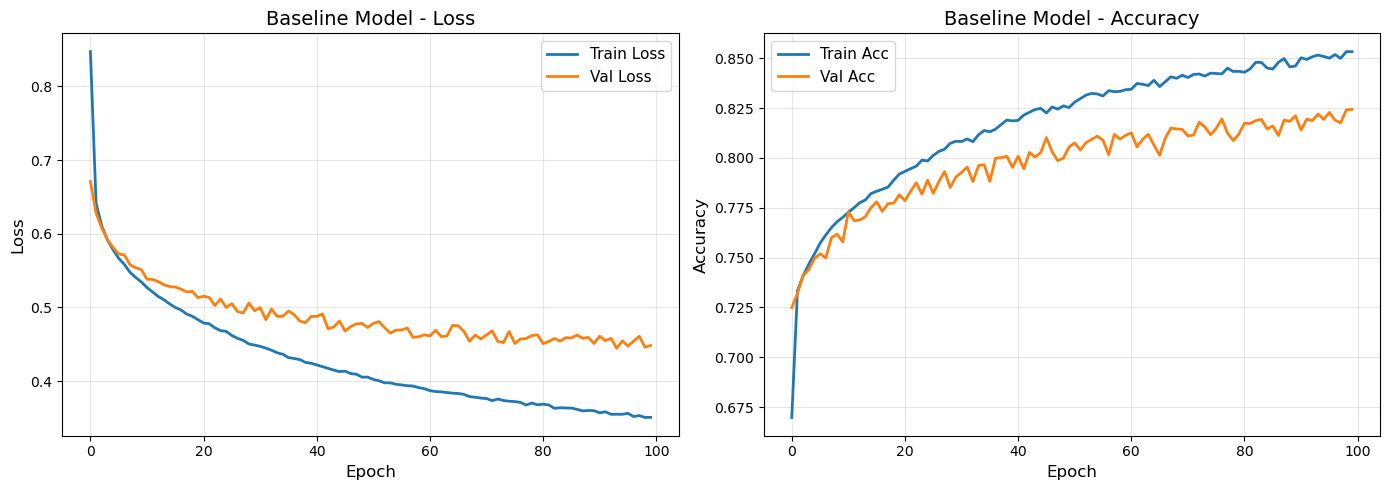


Final Metrics:
  Train Loss: 0.3509 | Train Acc: 0.8533
  Val Loss:   0.4485 | Val Acc:   0.8243


In [39]:
# Visualize baseline training
plot_training_history(baseline_history, "Baseline Model")

### Evaluate on Test Set

Let's see how our baseline model performs on the held-out test data.

In [40]:
def evaluate_model(model, test_loader):
    """
    Evaluate model on test set and return accuracy.
    """
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    accuracy = correct / total
    return accuracy


baseline_test_acc = evaluate_model(baseline_model, test_loader)
print(f"\n{'='*40}")
print(f"BASELINE TEST ACCURACY: {baseline_test_acc:.4f} ({baseline_test_acc*100:.1f}%)")
print(f"{'='*40}")


BASELINE TEST ACCURACY: 0.8271 (82.7%)


---

## Section 3: Regularization

Now let's add regularization techniques to prevent overfitting:

1. **L2 Regularization (Weight Decay)** - Shrinks weights toward zero
2. **Dropout** - Randomly "turns off" neurons during training

### L2 Regularization (Weight Decay)

L2 regularization adds a penalty proportional to the **square** of the weights. This encourages smaller weights but doesn't push them to exactly zero.

In PyTorch, we add L2 regularization via the `weight_decay` parameter in the optimizer.

In [41]:
# Create a fresh model for L2 regularization
l2_model = BaselineModel().to(device)

# The ONLY change: Add weight_decay to the optimizer
# This adds L2 penalty to the loss: Loss = CrossEntropy + (weight_decay/2) * sum(weights^2)
optimizer_l2 = optim.Adam(
    l2_model.parameters(), 
    lr=0.001,
    weight_decay=0.001  # L2 regularization strength (lambda)
)

print("Training with L2 Regularization (weight_decay=0.001)")
print("=" * 60)

l2_history = train_model(
    model=l2_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_l2,
    num_epochs=100
)

Training with L2 Regularization (weight_decay=0.001)
Epoch [ 10/100] | Train Loss: 0.5354 | Train Acc: 0.7707 | Val Loss: 0.5561 | Val Acc: 0.7648 | LR: 0.001000
Epoch [ 20/100] | Train Loss: 0.4882 | Train Acc: 0.7907 | Val Loss: 0.5172 | Val Acc: 0.7804 | LR: 0.001000
Epoch [ 30/100] | Train Loss: 0.4635 | Train Acc: 0.8025 | Val Loss: 0.4861 | Val Acc: 0.7934 | LR: 0.001000
Epoch [ 40/100] | Train Loss: 0.4470 | Train Acc: 0.8097 | Val Loss: 0.4778 | Val Acc: 0.8016 | LR: 0.001000
Epoch [ 50/100] | Train Loss: 0.4348 | Train Acc: 0.8179 | Val Loss: 0.4761 | Val Acc: 0.8001 | LR: 0.001000
Epoch [ 60/100] | Train Loss: 0.4281 | Train Acc: 0.8190 | Val Loss: 0.4711 | Val Acc: 0.8038 | LR: 0.001000
Epoch [ 70/100] | Train Loss: 0.4194 | Train Acc: 0.8238 | Val Loss: 0.4692 | Val Acc: 0.8060 | LR: 0.001000
Epoch [ 80/100] | Train Loss: 0.4140 | Train Acc: 0.8278 | Val Loss: 0.4624 | Val Acc: 0.8081 | LR: 0.001000
Epoch [ 90/100] | Train Loss: 0.4082 | Train Acc: 0.8296 | Val Loss: 0.4665

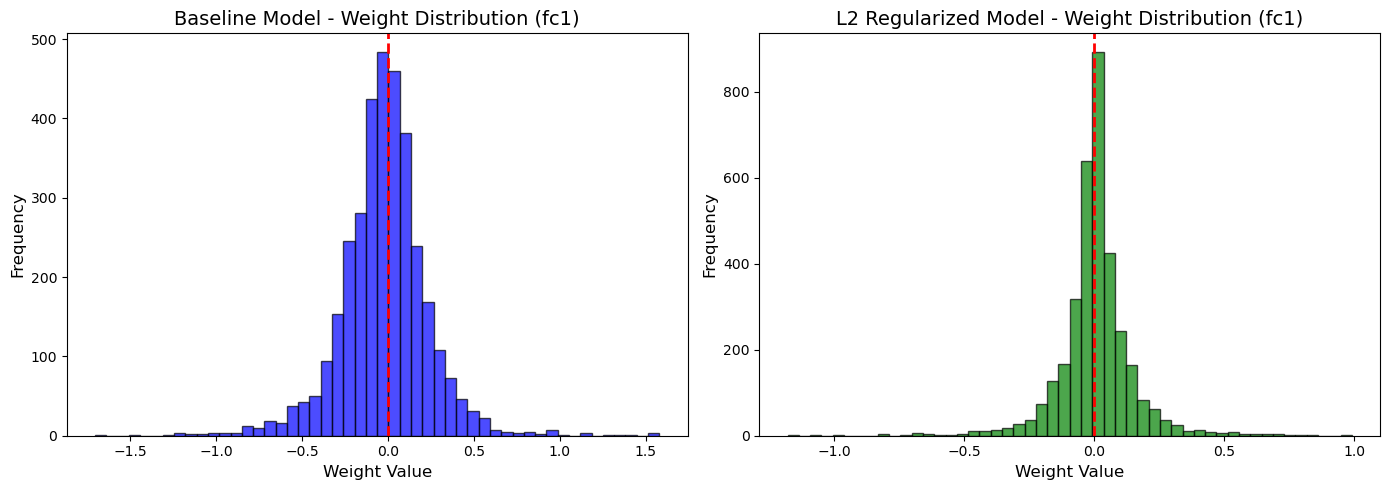

Baseline weights - Mean: -0.0231, Std: 0.2593
L2 weights       - Mean: 0.0029, Std: 0.1440

Notice: L2 regularization produces weights with SMALLER magnitude!


In [42]:
# Compare weight distributions: Baseline vs L2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect all weights from first layer
baseline_weights = baseline_model.fc1.weight.data.cpu().numpy().flatten()
l2_weights = l2_model.fc1.weight.data.cpu().numpy().flatten()

# Plot histograms
axes[0].hist(baseline_weights, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Baseline Model - Weight Distribution (fc1)', fontsize=14)
axes[0].set_xlabel('Weight Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[1].hist(l2_weights, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('L2 Regularized Model - Weight Distribution (fc1)', fontsize=14)
axes[1].set_xlabel('Weight Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print(f"Baseline weights - Mean: {baseline_weights.mean():.4f}, Std: {baseline_weights.std():.4f}")
print(f"L2 weights       - Mean: {l2_weights.mean():.4f}, Std: {l2_weights.std():.4f}")
print(f"\nNotice: L2 regularization produces weights with SMALLER magnitude!")

### Dropout

Dropout randomly "turns off" neurons during training with probability `p`. This prevents co-adaptation and acts as a form of ensemble learning.

**Key point:** Dropout is only active during training! During inference/evaluation, all neurons are used.

In [43]:
class DropoutModel(nn.Module):
    """
    Same architecture as baseline, but with Dropout layers added.
    """
    
    def __init__(self, input_size=54, hidden1=64, hidden2=32, num_classes=7, dropout_p=0.3):
        super(DropoutModel, self).__init__()
        
        # Layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        
        # Activation and regularization
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)  # 30% of neurons turned off
    
    def forward(self, x):
        # Layer 1 + Dropout
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout AFTER activation
        
        # Layer 2 + Dropout
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)  # Dropout here too
        
        # Output (no dropout on output layer)
        x = self.fc3(x)
        
        return x


# Create and train dropout model
dropout_model = DropoutModel(dropout_p=0.3).to(device)
optimizer_dropout = optim.Adam(dropout_model.parameters(), lr=0.001)

print("Training with Dropout (p=0.3)")
print("=" * 60)
print(dropout_model)
print()

Training with Dropout (p=0.3)
DropoutModel(
  (fc1): Linear(in_features=54, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)



In [44]:
# Demonstrate dropout behavior: training vs evaluation mode
print("DROPOUT BEHAVIOR DEMONSTRATION")
print("=" * 50)

# Get a sample input
sample_input = X_train_tensor[0:1].to(device)  # Single sample

# Training mode (dropout active)
dropout_model.train()
print("\nTraining mode (model.train()) - Dropout ACTIVE:")
for i in range(3):
    output = dropout_model(sample_input)
    print(f"  Run {i+1}: {output.detach().cpu().numpy().flatten()}")
print("  >> Notice: outputs are DIFFERENT each time (randomness from dropout)")

# Evaluation mode (dropout disabled)
dropout_model.eval()
print("\nEvaluation mode (model.eval()) - Dropout DISABLED:")
for i in range(3):
    with torch.no_grad():
        output = dropout_model(sample_input)
    print(f"  Run {i+1}: {output.detach().cpu().numpy().flatten()}")
print("  >> Notice: outputs are IDENTICAL (deterministic)")

DROPOUT BEHAVIOR DEMONSTRATION

Training mode (model.train()) - Dropout ACTIVE:
  Run 1: [-0.21813953  0.17696661  0.2512497   0.305691   -0.15653647  0.22647513
 -0.3874699 ]
  Run 2: [ 0.01869936  0.06830601  0.01451964  0.01948431  0.28170198 -0.11796951
 -0.7360127 ]
  Run 3: [-0.06410722 -0.22418058  0.07921811  0.292915   -0.11727476 -0.06164722
 -0.38577157]
  >> Notice: outputs are DIFFERENT each time (randomness from dropout)

Evaluation mode (model.eval()) - Dropout DISABLED:
  Run 1: [-0.01696405 -0.04107295  0.23617661  0.12712927 -0.10173368  0.1424901
 -0.4721139 ]
  Run 2: [-0.01696405 -0.04107295  0.23617661  0.12712927 -0.10173368  0.1424901
 -0.4721139 ]
  Run 3: [-0.01696405 -0.04107295  0.23617661  0.12712927 -0.10173368  0.1424901
 -0.4721139 ]
  >> Notice: outputs are IDENTICAL (deterministic)


In [45]:
# Train dropout model
dropout_history = train_model(
    model=dropout_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_dropout,
    num_epochs=100
)

Epoch [ 10/100] | Train Loss: 0.6269 | Train Acc: 0.7372 | Val Loss: 0.5826 | Val Acc: 0.7488 | LR: 0.001000
Epoch [ 20/100] | Train Loss: 0.5916 | Train Acc: 0.7501 | Val Loss: 0.5508 | Val Acc: 0.7581 | LR: 0.001000
Epoch [ 30/100] | Train Loss: 0.5773 | Train Acc: 0.7537 | Val Loss: 0.5395 | Val Acc: 0.7657 | LR: 0.001000
Epoch [ 40/100] | Train Loss: 0.5673 | Train Acc: 0.7580 | Val Loss: 0.5292 | Val Acc: 0.7656 | LR: 0.001000
Epoch [ 50/100] | Train Loss: 0.5585 | Train Acc: 0.7591 | Val Loss: 0.5232 | Val Acc: 0.7686 | LR: 0.001000
Epoch [ 60/100] | Train Loss: 0.5517 | Train Acc: 0.7616 | Val Loss: 0.5193 | Val Acc: 0.7715 | LR: 0.001000
Epoch [ 70/100] | Train Loss: 0.5441 | Train Acc: 0.7636 | Val Loss: 0.5104 | Val Acc: 0.7745 | LR: 0.001000
Epoch [ 80/100] | Train Loss: 0.5419 | Train Acc: 0.7657 | Val Loss: 0.5085 | Val Acc: 0.7832 | LR: 0.001000
Epoch [ 90/100] | Train Loss: 0.5387 | Train Acc: 0.7661 | Val Loss: 0.5051 | Val Acc: 0.7819 | LR: 0.001000
Epoch [100/100] | T

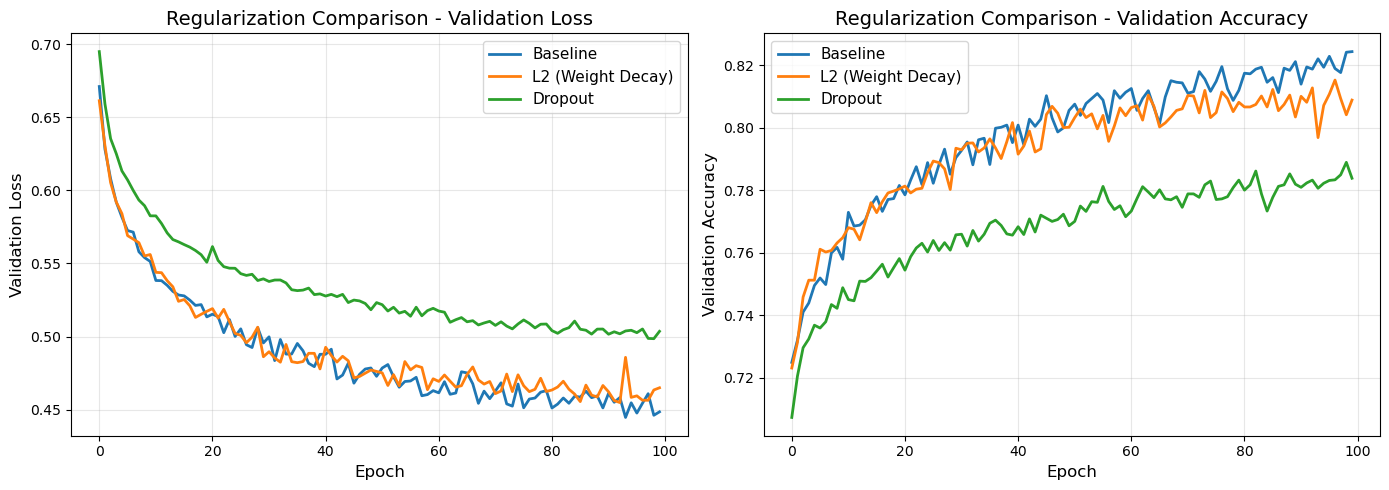

In [46]:
# Compare all regularization techniques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(baseline_history['val_loss'], label='Baseline', linewidth=2)
axes[0].plot(l2_history['val_loss'], label='L2 (Weight Decay)', linewidth=2)
axes[0].plot(dropout_history['val_loss'], label='Dropout', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].set_title('Regularization Comparison - Validation Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(baseline_history['val_acc'], label='Baseline', linewidth=2)
axes[1].plot(l2_history['val_acc'], label='L2 (Weight Decay)', linewidth=2)
axes[1].plot(dropout_history['val_acc'], label='Dropout', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Regularization Comparison - Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Section 4: Batch Normalization

Batch Normalization normalizes the inputs to each layer, making training faster and more stable.

**The 4-Step Process:**
1. Calculate batch mean (μ)
2. Calculate batch variance (σ²)
3. Normalize: (x - μ) / √(σ² + ε)
4. Scale and shift: γ * normalized + β

In [47]:
class BatchNormModel(nn.Module):
    """
    Model with Batch Normalization layers added after each hidden layer.
    """
    
    def __init__(self, input_size=54, hidden1=64, hidden2=32, num_classes=7):
        super(BatchNormModel, self).__init__()
        
        # Layers with BatchNorm
        self.fc1 = nn.Linear(input_size, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)  # BatchNorm for hidden1 outputs
        
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)  # BatchNorm for hidden2 outputs
        
        self.fc3 = nn.Linear(hidden2, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Layer 1: Linear -> BatchNorm -> ReLU
        x = self.fc1(x)
        x = self.bn1(x)  # Normalize before activation
        x = self.relu(x)
        
        # Layer 2: Linear -> BatchNorm -> ReLU
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        
        # Output (no BatchNorm on output)
        x = self.fc3(x)
        
        return x


bn_model = BatchNormModel().to(device)
print("Model with Batch Normalization:")
print(bn_model)

Model with Batch Normalization:
BatchNormModel(
  (fc1): Linear(in_features=54, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)


In [48]:
# Let's see BatchNorm in action step by step
print("\nBATCH NORMALIZATION - STEP BY STEP")
print("=" * 60)

# Get a batch of data
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)
print(f"Input batch shape: {sample_batch.shape}")

# Pass through first linear layer (before BatchNorm)
bn_model.train()  # Make sure we're in training mode
with torch.no_grad():
    after_fc1 = bn_model.fc1(sample_batch)
    print(f"\nAfter fc1 (before BatchNorm):")
    print(f"  Shape: {after_fc1.shape}")
    print(f"  Mean per feature (first 5): {after_fc1.mean(dim=0)[:5].cpu().numpy()}")
    print(f"  Std per feature (first 5):  {after_fc1.std(dim=0)[:5].cpu().numpy()}")
    
    # Now apply BatchNorm
    after_bn1 = bn_model.bn1(after_fc1)
    print(f"\nAfter BatchNorm:")
    print(f"  Mean per feature (first 5): {after_bn1.mean(dim=0)[:5].cpu().numpy()}")
    print(f"  Std per feature (first 5):  {after_bn1.std(dim=0)[:5].cpu().numpy()}")
    print(f"\n>> Notice: Mean ≈ 0, Std ≈ 1 after BatchNorm!")


BATCH NORMALIZATION - STEP BY STEP
Input batch shape: torch.Size([64, 54])

After fc1 (before BatchNorm):
  Shape: torch.Size([64, 64])
  Mean per feature (first 5): [ 0.06050406  0.03824348 -0.13434613 -0.20828807  0.11246216]
  Std per feature (first 5):  [0.7807258  0.6258456  0.5607824  0.5451744  0.58756554]

After BatchNorm:
  Mean per feature (first 5): [-6.5192580e-09 -1.8626451e-08  2.6077032e-08  2.2351742e-08
  1.4901161e-08]
  Std per feature (first 5):  [1.0078969 1.0078923 1.007889  1.0078881 1.0078905]

>> Notice: Mean ≈ 0, Std ≈ 1 after BatchNorm!


In [49]:
# Train the BatchNorm model
optimizer_bn = optim.Adam(bn_model.parameters(), lr=0.001)

print("\nTraining with Batch Normalization")
print("=" * 60)

bn_history = train_model(
    model=bn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_bn,
    num_epochs=100
)


Training with Batch Normalization
Epoch [ 10/100] | Train Loss: 0.5119 | Train Acc: 0.7804 | Val Loss: 0.5178 | Val Acc: 0.7813 | LR: 0.001000
Epoch [ 20/100] | Train Loss: 0.4680 | Train Acc: 0.7996 | Val Loss: 0.4851 | Val Acc: 0.8006 | LR: 0.001000
Epoch [ 30/100] | Train Loss: 0.4453 | Train Acc: 0.8077 | Val Loss: 0.4605 | Val Acc: 0.8073 | LR: 0.001000
Epoch [ 40/100] | Train Loss: 0.4275 | Train Acc: 0.8142 | Val Loss: 0.4542 | Val Acc: 0.8146 | LR: 0.001000
Epoch [ 50/100] | Train Loss: 0.4163 | Train Acc: 0.8212 | Val Loss: 0.4422 | Val Acc: 0.8200 | LR: 0.001000
Epoch [ 60/100] | Train Loss: 0.4099 | Train Acc: 0.8235 | Val Loss: 0.4289 | Val Acc: 0.8255 | LR: 0.001000
Epoch [ 70/100] | Train Loss: 0.3999 | Train Acc: 0.8280 | Val Loss: 0.4225 | Val Acc: 0.8312 | LR: 0.001000
Epoch [ 80/100] | Train Loss: 0.3907 | Train Acc: 0.8321 | Val Loss: 0.4272 | Val Acc: 0.8310 | LR: 0.001000
Epoch [ 90/100] | Train Loss: 0.3875 | Train Acc: 0.8315 | Val Loss: 0.4208 | Val Acc: 0.8339

In [50]:
# Check learned parameters after training
print("\nAFTER TRAINING - BatchNorm learned parameters:")
print("=" * 50)
print(f"γ (gamma) - scale (first 5): {bn_model.bn1.weight.data[:5].cpu().numpy()}")
print(f"β (beta) - shift (first 5):  {bn_model.bn1.bias.data[:5].cpu().numpy()}")
print(f"\n>> Notice: γ and β have changed - the network learned optimal scaling!")

print(f"\nRunning statistics (accumulated during training):")
print(f"  Running mean (first 5): {bn_model.bn1.running_mean[:5].cpu().numpy()}")
print(f"  Running var (first 5):  {bn_model.bn1.running_var[:5].cpu().numpy()}")


AFTER TRAINING - BatchNorm learned parameters:
γ (gamma) - scale (first 5): [1.0582081  0.78044224 0.8805088  1.083192   0.8955919 ]
β (beta) - shift (first 5):  [-0.17462276 -0.23914815  0.13324323 -0.17953888 -0.16145009]

>> Notice: γ and β have changed - the network learned optimal scaling!

Running statistics (accumulated during training):
  Running mean (first 5): [ 0.0270569   0.05709497 -0.13619058 -0.05855139 -0.02799446]
  Running var (first 5):  [0.75592077 2.7607217  2.9462795  0.92105407 3.847004  ]


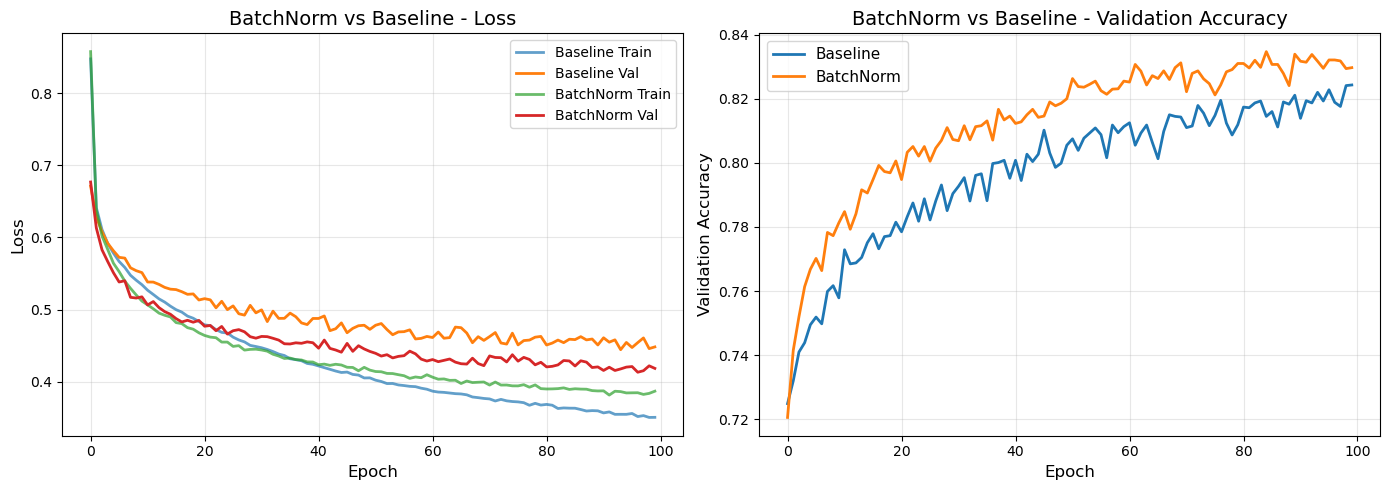

In [51]:
# Compare BatchNorm vs Baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history['train_loss'], label='Baseline Train', linewidth=2, alpha=0.7)
axes[0].plot(baseline_history['val_loss'], label='Baseline Val', linewidth=2)
axes[0].plot(bn_history['train_loss'], label='BatchNorm Train', linewidth=2, alpha=0.7)
axes[0].plot(bn_history['val_loss'], label='BatchNorm Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('BatchNorm vs Baseline - Loss', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(baseline_history['val_acc'], label='Baseline', linewidth=2)
axes[1].plot(bn_history['val_acc'], label='BatchNorm', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('BatchNorm vs Baseline - Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Section 5: Learning Rate Scheduling

Learning rate scheduling adjusts the learning rate during training. **ReduceLROnPlateau** is particularly useful - it reduces the learning rate when the validation loss stops improving.

In [52]:
# Create a fresh model for LR scheduling demo
lr_model = BatchNormModel().to(device)  # Using our BatchNorm model
optimizer_lr = optim.Adam(lr_model.parameters(), lr=0.01)  # Start with higher LR

# Create ReduceLROnPlateau scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lr,
    mode='min',       # Reduce LR when metric stops decreasing
    factor=0.5,       # Multiply LR by 0.5 when reducing
    patience=10,      # Wait 10 epochs before reducing
    verbose=True,     # Print when LR changes
    min_lr=1e-6       # Don't reduce below this
)

print("ReduceLROnPlateau Configuration:")
print(f"  - Starting LR: 0.01")
print(f"  - Factor: 0.5 (LR *= 0.5 when triggered)")
print(f"  - Patience: 10 epochs")
print(f"  - Min LR: 1e-6")

ReduceLROnPlateau Configuration:
  - Starting LR: 0.01
  - Factor: 0.5 (LR *= 0.5 when triggered)
  - Patience: 10 epochs
  - Min LR: 1e-6


/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [53]:
# Train with LR scheduling
print("\nTraining with ReduceLROnPlateau Scheduler")
print("=" * 60)

lr_history = train_model(
    model=lr_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_lr,
    scheduler=scheduler,  # Pass the scheduler!
    num_epochs=150  # Train longer to see LR changes
)


Training with ReduceLROnPlateau Scheduler
Epoch [ 10/150] | Train Loss: 0.5053 | Train Acc: 0.7795 | Val Loss: 0.5091 | Val Acc: 0.7791 | LR: 0.010000
Epoch [ 20/150] | Train Loss: 0.4613 | Train Acc: 0.8004 | Val Loss: 0.4809 | Val Acc: 0.7969 | LR: 0.010000
Epoch [ 30/150] | Train Loss: 0.4442 | Train Acc: 0.8089 | Val Loss: 0.4625 | Val Acc: 0.8050 | LR: 0.010000
Epoch [ 40/150] | Train Loss: 0.4293 | Train Acc: 0.8141 | Val Loss: 0.4424 | Val Acc: 0.8142 | LR: 0.010000
Epoch [ 50/150] | Train Loss: 0.4175 | Train Acc: 0.8187 | Val Loss: 0.4381 | Val Acc: 0.8209 | LR: 0.010000
Epoch [ 60/150] | Train Loss: 0.4092 | Train Acc: 0.8231 | Val Loss: 0.4362 | Val Acc: 0.8211 | LR: 0.010000
Epoch [ 70/150] | Train Loss: 0.3759 | Train Acc: 0.8383 | Val Loss: 0.4165 | Val Acc: 0.8306 | LR: 0.005000
Epoch [ 80/150] | Train Loss: 0.3800 | Train Acc: 0.8372 | Val Loss: 0.4129 | Val Acc: 0.8315 | LR: 0.005000
Epoch [ 90/150] | Train Loss: 0.3748 | Train Acc: 0.8367 | Val Loss: 0.4213 | Val Acc

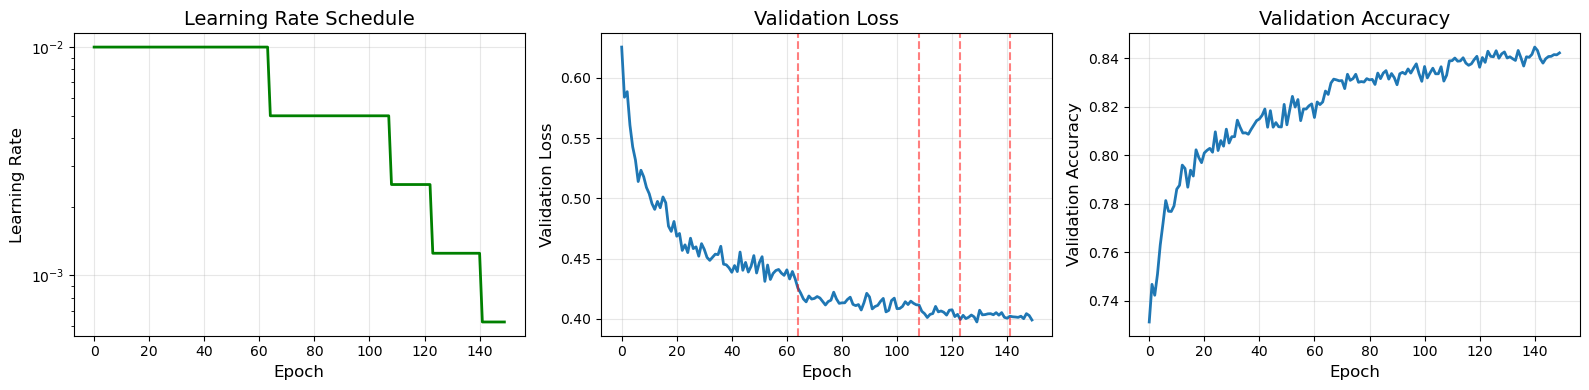


Learning rate was reduced at epochs: [64, 108, 123, 141]
Final learning rate: 6.25e-04


In [54]:
# Visualize learning rate changes over training
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Learning rate over time
axes[0].plot(lr_history['learning_rates'], linewidth=2, color='green')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('Learning Rate Schedule', fontsize=14)
axes[0].set_yscale('log')  # Log scale to see changes better
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation loss
axes[1].plot(lr_history['val_loss'], linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Validation Loss', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Mark where LR changed
lr_changes = []
for i in range(1, len(lr_history['learning_rates'])):
    if lr_history['learning_rates'][i] != lr_history['learning_rates'][i-1]:
        lr_changes.append(i)
        axes[1].axvline(x=i, color='red', linestyle='--', alpha=0.5)

# Plot 3: Validation accuracy
axes[2].plot(lr_history['val_acc'], linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Validation Accuracy', fontsize=12)
axes[2].set_title('Validation Accuracy', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLearning rate was reduced at epochs: {lr_changes}")
print(f"Final learning rate: {lr_history['learning_rates'][-1]:.2e}")

---

## Summary: What We Learned

### Regularization Techniques
- **L2 (Weight Decay)**: Shrinks weights toward zero, prevents large weights
- **Dropout**: Randomly turns off neurons, prevents co-adaptation

### Normalization
- **BatchNorm**: Normalizes layer inputs, stabilizes training, allows higher learning rates

### Learning Rate Scheduling
- **ReduceLROnPlateau**: Automatically reduces LR when validation loss plateaus

### Key Takeaways
- Start with a simple baseline, then add techniques **one at a time**
- Compare each technique against the baseline to see its effect
- Not every technique helps every dataset — experiment and measure!

---

**You now have a solid PyTorch toolkit for building deep learning models!**